<a href="https://colab.research.google.com/github/reitezuz/18NES1-2026/blob/main/week09/prepare_ants_bees.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Loading the Bees vs. Ants Dataset

The Bees vs. Spiders dataset is a collection of images for binary image classification. It contains a training set of labeled images of bees and ants. Each image is a color photograph. The dataset represents a visually diverse classification problem, as the two categories differ in structure, texture, and typical background, making it suitable for experimenting with convolutional neural networks.

The dataset is available at:
https://download.pytorch.org/tutorial/hymenoptera_data.zip

1. Download the zip file with the data
2. Extract the zip file

In [ ]:
import os
import zipfile
import urllib.request

# target directory
data_dir = "data"
os.makedirs(data_dir, exist_ok=True)

# dataset URL
url = "https://download.pytorch.org/tutorial/hymenoptera_data.zip"
zip_path = os.path.join(data_dir, "ants_bees.zip")

# download
if not os.path.exists(zip_path):
    print("Downloading dataset...")
    urllib.request.urlretrieve(url, zip_path)
    print("Download complete.")

# unzip
extract_path = os.path.join(data_dir, "ants_bees")

if not os.path.exists(extract_path):
    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(data_dir)
    print("Extraction complete.")

print("Dataset ready at:", os.path.join(data_dir, "hymenoptera_data"))

Download complete.
Extracting dataset...
Extraction complete.
Dataset ready at: data/hymenoptera_data


## Process the data

### The format (structure) of the folder with data:
- in our case, the root folder contains three subdirectories: train, validation, and test:
in our case, the root folder contains three subdirectories: `train` (2000 images), `validation` (1000 images), and `test` (2000 images):

```
data/
└── hymenoptera_data/
    ├── train/
    │   ├── ants/
    │   └── bees/
    └── val/
        ├── ants/
        └── bees/
```

Observe the number of images in each folder:


In [ ]:
import os

base_dir = "data/hymenoptera_data"

for split in ["train", "val"]:
    split_dir = os.path.join(base_dir, split)
    print(f"\n{split.upper()}:")
    for category in ["ants", "bees"]:
        category_dir = os.path.join(split_dir, category)
        num_images = len(os.listdir(category_dir))
        print(f"  {category}: {num_images} images")


TRAIN:
  ants: 124 images
  bees: 121 images

VAL:
  ants: 70 images
  bees: 83 images


Split the validation set into validation and test

In [ ]:
import os
import shutil
import random

# set seed for reproducibility
random.seed(42)

base_dir = "data/hymenoptera_data"
val_dir = os.path.join(base_dir, "val")

validation_dir = os.path.join(base_dir, "validation")
test_dir = os.path.join(base_dir, "test")

# create target directories
for split_dir in [validation_dir, test_dir]:
    for cls in ["ants", "bees"]:
        os.makedirs(os.path.join(split_dir, cls), exist_ok=True)

# split data into validation and test
for cls in ["ants", "bees"]:
    src_dir = os.path.join(val_dir, cls)
    images = os.listdir(src_dir)

    # shuffle images randomly
    random.shuffle(images)

    # split 50/50
    split_idx = len(images) // 2
    val_images = images[:split_idx]
    test_images = images[split_idx:]

    # copy images to validation set
    for img in val_images:
        shutil.copy(
            os.path.join(src_dir, img),
            os.path.join(validation_dir, cls, img)
        )

    # copy images to test set
    for img in test_images:
        shutil.copy(
            os.path.join(src_dir, img),
            os.path.join(test_dir, cls, img)
        )

# remove original val directory
shutil.rmtree(val_dir)

print("Done. Validation and test sets created, original 'val' removed.")



Done. Validation and test sets created, original 'val' removed.


In [ ]:
import os

base_dir = "data/hymenoptera_data"

for split in ["train", "validation", "test"]:
    split_dir = os.path.join(base_dir, split)
    print(f"\n{split.upper()}:")
    for category in ["ants", "bees"]:
        category_dir = os.path.join(split_dir, category)
        num_images = len(os.listdir(category_dir))
        print(f"  {category}: {num_images} images")


TRAIN:
  ants: 124 images
  bees: 121 images

VALIDATION:
  ants: 35 images
  bees: 41 images

TEST:
  ants: 35 images
  bees: 42 images


Observe some images:

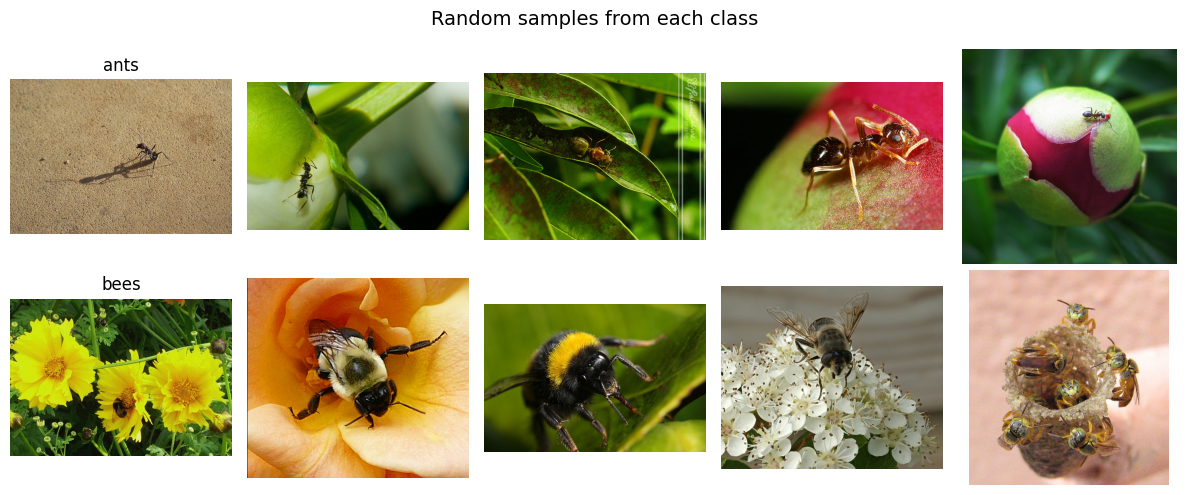

In [ ]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

base_dir = "data/hymenoptera_data/train"
classes = ["ants", "bees"]

fig, axes = plt.subplots(len(classes), 5, figsize=(12, 5))
fig.suptitle("Random samples from each class", fontsize=14)

for i, cls in enumerate(classes):
    class_dir = os.path.join(base_dir, cls)
    images = random.sample(os.listdir(class_dir), 5)

    for j, img_name in enumerate(images):
        img_path = os.path.join(class_dir, img_name)
        img = mpimg.imread(img_path)
        axes[i, j].imshow(img)
        axes[i, j].axis("off")
        if j == 0:
            axes[i, j].set_title(cls)

plt.tight_layout()
plt.show()